In [1]:
import gcinfo

gcinfo.search_titles(query="non permanent by type")

Estimates of the number of non-permanent residents by type, quarterly
Non-permanent resident type by place of birth: Canada, provinces and territories, census metropolitan areas and census agglomerations with parts
Estimates of the number of non-permanent residents on July 1, by age and gender
Estimates of non-permanent residents as of July 1st, by age and sex, inactive
Job permanency (permanent and temporary) by industry, monthly, unadjusted for seasonality
Building permits, non-residential values by type of structure
Employment in the non-profit sector by type of worker
Employee wages by job permanency and union coverage, annual
Immigrants to Canada, by country of last permanent residence
Non-bank mortgages extended, by lender type, insurance status and mortgage characteristics
Non-bank mortgages outstanding, by lender type, insurance status and mortgage characteristics
Capital expenditures, non-residential tangible assets, by type of asset and geography
Capital expenditures, non-res

In [2]:
gcinfo.list_resources(gcinfo.search_datasets(query='title:"Non-permanent resident type by place of birth: Canada, provinces and territories, census metropolitan areas and census agglomerations with parts"')["results"][0])


=== Non-permanent resident type by place of birth: Canada, provinces and territories, census metropolitan areas and census agglomerations with parts ===
ID: 64d9dd72-2c5b-4eac-9c82-f3160f15d267
Org: Statistics Canada | Statistique Canada
Notes: Data on non-permanent resident type by place of birth, age and gender for the population in private households in Canada, provinces and territories, census metropolitan areas, census agglomerations an...
URL: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=9810036101
Citation: Statistics Canada. Table 98-10-0361-01 Non-permanent resident type by place of birth: Canada, provinces and territories, census metropolitan areas and census agglomerations with parts
DOI:      https://doi.org/10.25318/9810036101-eng
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/98100361-fra.zip
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/98100361-eng.zip
  [XML     ] Dataset
           https://www150.statcan.gc.

In [3]:
"""
Non-permanent resident type by place of birth:
Canada, provinces and territories, census metropolitan areas and census agglomerations with parts

Total - Place of birth has:
- Inside Canada
- Outside Canada

When Place of birth is Inside Canada, Non-permanent residents is 0.
When Place of birth is Outside Canada, Non-permanent residents is not always 0.

Outside Canada is grouped into subsets.

Americas Non-permanent residents is 154,080, Americas contains Non-permanent residents from:
- North America 26,860
- Central America 39,480
- Caribbean and Bermuda 26,630
- South America 61,110
>>> 26860+39480+26630+61110
154080

North America (26,860) contains Greenland (0), Saint Pierre and Miquelon (50), United States of America (26,805), and not Canada.
>>> 0 + 50 + 26805
26855

This is due to "Random rounding":
https://www12.statcan.gc.ca/census-recensement/2011/dp-pd/prof/help-aide/N2.cfm?Lang=E
Census Profile - Random rounding
To ensure confidentiality, the values, including totals, are randomly rounded either up
or down to a multiple of '5' or '10.' To understand these data, you must be aware that
each individual value is rounded. As a result, when these data are summed or grouped,
the total value may not match the individual values since totals and sub-totals are
independently rounded. Similarly, percentages, which are calculated on rounded data,
may not necessarily add up to 100%.
"""

'\nNon-permanent resident type by place of birth:\nCanada, provinces and territories, census metropolitan areas and census agglomerations with parts\n\nTotal - Place of birth has:\n- Inside Canada\n- Outside Canada\n\nWhen Place of birth is Inside Canada, Non-permanent residents is 0.\nWhen Place of birth is Outside Canada, Non-permanent residents is not always 0.\n\nOutside Canada is grouped into subsets.\n\nAmericas Non-permanent residents is 154,080, Americas contains Non-permanent residents from:\n- North America 26,860\n- Central America 39,480\n- Caribbean and Bermuda 26,630\n- South America 61,110\n>>> 26860+39480+26630+61110\n154080\n\nNorth America (26,860) contains Greenland (0), Saint Pierre and Miquelon (50), United States of America (26,805), and not Canada.\n>>> 0 + 50 + 26805\n26855\n\nThis is due to "Random rounding":\nhttps://www12.statcan.gc.ca/census-recensement/2011/dp-pd/prof/help-aide/N2.cfm?Lang=E\nCensus Profile - Random rounding\nTo ensure confidentiality, the 

In [4]:
df, df_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/98100361-eng.zip")

Using cached file: cache\98100361-eng.zip


In [5]:
df_canada = df[df["GEO"] == "Canada"]
df_canada["GEO"].astype(str).unique()

array(['Canada'], dtype=object)

In [6]:
df_canada["REF_DATE"].unique()

array([2021])

In [7]:
df_canada.head()

,REF_DATE,GEO,DGUID,Gender (3),Age (15C),Statistics (3),Place of birth (290),Coordinate,Non-permanent resident type (10):Total - Non-permanent resident type[1],Symbol,...,Non-permanent resident type (10):Non-permanent residents with work and study permits[6],Symbol.5,Non-permanent resident type (10):Other non-permanent resident types[7],Symbol.6,Non-permanent resident type (10):Not a non-permanent resident[8],Symbol.7,Non-permanent resident type (10):Non-immigrants[9],Symbol.8,Non-permanent resident type (10):Immigrants[10],Symbol.9
0,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Total – Place of birth,1.1.1.1.1,36328480,NaN,...,131560,NaN,80870,NaN,35403630,NaN,27042125,NaN,8361505,NaN
1,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Inside Canada,1.1.1.1.2,26721875,NaN,...,0,NaN,0,NaN,26721875,NaN,26719590,NaN,2290,NaN
2,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Newfoundland and Labrador,1.1.1.1.3,636150,NaN,...,0,NaN,0,NaN,636150,NaN,636095,NaN,55,NaN
3,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Prince Edward Island,1.1.1.1.4,140505,NaN,...,0,NaN,0,NaN,140505,NaN,140495,NaN,10,NaN
4,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Nova Scotia,1.1.1.1.5,911445,NaN,...,0,NaN,0,NaN,911445,NaN,911335,NaN,105,NaN


In [8]:
# df_canada["Place of birth (290)"].astype(str).unique()
"""
array(['Total – Place of birth', 'Inside Canada',
       'Newfoundland and Labrador', 'Prince Edward Island', 'Nova Scotia',
       'New Brunswick', 'Quebec', 'Ontario', 'Manitoba', 'Saskatchewan',
       'Alberta', 'British Columbia', 'Yukon', 'Northwest Territories',
       'Nunavut', 'Outside Canada', 'Americas', 'North America',
       'Greenland', 'Saint Pierre and Miquelon',
       'United States of America', 'Central America', 'Belize',
       'Costa Rica', 'El Salvador', 'Guatemala', 'Honduras', 'Mexico',
       'Nicaragua', 'Panama', 'Caribbean and Bermuda', 'Anguilla',
       'Antigua and Barbuda', 'Aruba', 'Bahamas', 'Barbados', 'Bermuda',
       'Bonaire, Sint Eustatius and Saba', 'Cayman Islands', 'Cuba',
       'Curaçao', 'Dominica', 'Dominican Republic', 'Grenada',
       'Guadeloupe', 'Haiti', 'Jamaica', 'Martinique', 'Montserrat',
       'Puerto Rico', 'Saint Barthélemy', 'Saint Kitts and Nevis',
       'Saint Lucia', 'Saint Martin (French part)',
       'Saint Vincent and the Grenadines', 'Sint Maarten (Dutch part)',
       'Trinidad and Tobago', 'Turks and Caicos Islands',
       'Virgin Islands, British', 'Virgin Islands, United States',
       'South America', 'Argentina', 'Bolivia', 'Brazil', 'Chile',
       'Colombia', 'Ecuador', 'Falkland Islands (Malvinas)',
       'French Guiana', 'Guyana', 'Paraguay', 'Peru',
       'South Georgia and the South Sandwich Islands', 'Suriname',
       'Uruguay', 'Venezuela', 'Europe', 'Western Europe', 'Austria',
       'Belgium', 'France', 'Germany', 'Liechtenstein', 'Luxembourg',
       'Monaco', 'Netherlands', 'Switzerland', 'Eastern Europe',
       'Belarus', 'Bulgaria', 'Czechia', 'Estonia', 'Hungary', 'Latvia',
       'Lithuania', 'Moldova', 'Poland', 'Romania', 'Russian Federation',
       'Slovakia', 'Ukraine', 'Northern Europe', 'Åland Islands',
       'Denmark', 'Faroe Islands', 'Finland', 'Guernsey', 'Iceland',
       'Ireland', 'Isle of Man', 'Jersey', 'Norway', 'Sark',
       'Svalbard and Jan Mayen', 'Sweden', 'United Kingdom',
       'Southern Europe', 'Albania', 'Andorra', 'Bosnia and Herzegovina',
       'Croatia', 'Gibraltar', 'Greece', 'Holy See (Vatican City State)',
       'Italy', 'Kosovo', 'Malta', 'Montenegro', 'North Macedonia',
       'Portugal', 'San Marino', 'Serbia', 'Slovenia', 'Spain', 'Africa',
       'Western Africa', 'Benin', 'Burkina Faso', 'Cabo Verde',
       "Côte d'Ivoire", 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau',
       'Liberia', 'Mali', 'Mauritania', 'Niger', 'Nigeria',
       'Saint Helena, Ascension and Tristan da Cunha', 'Senegal',
       'Sierra Leone', 'Togo', 'Eastern Africa', 'Burundi', 'Comoros',
       'Djibouti', 'Eritrea', 'Ethiopia', 'Kenya', 'Madagascar', 'Malawi',
       'Mauritius', 'Mayotte', 'Mozambique', 'Réunion', 'Rwanda',
       'Seychelles', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda',
       'Zambia', 'Zimbabwe', 'Northern Africa', 'Algeria', 'Egypt',
       'Libya', 'Morocco', 'Sudan', 'Tunisia', 'Western Sahara',
       'Central Africa', 'Angola', 'Cameroon', 'Central African Republic',
       'Chad', 'Congo, Democratic Republic of the',
       'Congo, Republic of the', 'Equatorial Guinea', 'Gabon',
       'Sao Tome and Principe', 'Southern Africa', 'Botswana', 'Eswatini',
       'Lesotho', 'Namibia', 'South Africa, Republic of', 'Asia',
       'West Central Asia and the Middle East', 'Afghanistan', 'Armenia',
       'Azerbaijan', 'Bahrain', 'Cyprus', 'Georgia', 'Iran', 'Iraq',
       'Israel', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan',
       'Lebanon', 'Oman', 'Qatar', 'Saudi Arabia', 'Syria', 'Tajikistan',
       'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan',
       'West Bank and Gaza Strip', 'Yemen', 'Eastern Asia', 'China',
       'Hong Kong', 'Japan', 'Korea, North', 'Korea, South', 'Macao',
       'Mongolia', 'Taiwan', 'Southeast Asia', 'Brunei Darussalam',
       'Cambodia', 'Indonesia', 'Laos', 'Malaysia', 'Myanmar',
       'Philippines', 'Singapore', 'Thailand', 'Timor-Leste', 'Viet Nam',
       'Southern Asia', 'Bangladesh', 'Bhutan',
       'British Indian Ocean Territory', 'India', 'Maldives', 'Nepal',
       'Pakistan', 'Sri Lanka', 'Oceania', 'American Samoa', 'Australia',
       'Christmas Island', 'Cocos (Keeling) Islands', 'Cook Islands',
       'Fiji', 'French Polynesia', 'Guam', 'Kiribati', 'Marshall Islands',
       'Micronesia, Federated States of', 'Nauru', 'New Caledonia',
       'New Zealand', 'Niue', 'Norfolk Island',
       'Northern Mariana Islands', 'Palau', 'Papua New Guinea',
       'Pitcairn', 'Samoa', 'Solomon Islands', 'Tokelau', 'Tonga',
       'Tuvalu', 'United States Minor Outlying Islands', 'Vanuatu',
       'Wallis and Futuna', 'Antarctica and Adjacent Islands',
       'Antarctica', 'Bouvet Island', 'French Southern Territories',
       'Heard Island and McDonald Islands', 'Other'], dtype=object)
""";

In [9]:
aggregates = ["Total – Place of birth",

              "Inside Canada",
              "Newfoundland and Labrador", "Prince Edward Island", "Nova Scotia", "New Brunswick", "Quebec", "Ontario", "Manitoba",
              "Saskatchewan", "Alberta", "British Columbia", "Yukon", "Northwest Territories", "Nunavut",

              "Outside Canada",
              "Americas",
              "North America", "Central America", "Caribbean and Bermuda", "South America",
              "Europe",
              "Western Europe", "Eastern Europe", "Northern Europe", "Southern Europe",
              "Africa",
              "Western Africa", "Eastern Africa", "Northern Africa", "Central Africa", "Southern Africa",
              "Asia",
              "West Central Asia and the Middle East", "Eastern Asia", "Southeast Asia", "Southern Asia",
              "Oceania",
              "Antarctica and Adjacent Islands",
              "Other",
]

In [10]:
df_canada_nations = df_canada[~df_canada["Place of birth (290)"].isin(aggregates)]
df_canada_nations.head()

,REF_DATE,GEO,DGUID,Gender (3),Age (15C),Statistics (3),Place of birth (290),Coordinate,Non-permanent resident type (10):Total - Non-permanent resident type[1],Symbol,...,Non-permanent resident type (10):Non-permanent residents with work and study permits[6],Symbol.5,Non-permanent resident type (10):Other non-permanent resident types[7],Symbol.6,Non-permanent resident type (10):Not a non-permanent resident[8],Symbol.7,Non-permanent resident type (10):Non-immigrants[9],Symbol.8,Non-permanent resident type (10):Immigrants[10],Symbol.9
18,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Greenland,1.1.1.1.19,30,NaN,...,0,NaN,0,NaN,25,NaN,0,NaN,25,NaN
19,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Saint Pierre and Miquelon,1.1.1.1.20,510,NaN,...,15,NaN,0,NaN,465,NaN,105,NaN,355,NaN
20,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,United States of America,1.1.1.1.21,373380,NaN,...,1155,NaN,4565,NaN,346575,NaN,90485,NaN,256085,NaN
22,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Belize,1.1.1.1.23,2940,NaN,...,30,NaN,15,NaN,2750,NaN,735,NaN,2015,NaN
23,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Costa Rica,1.1.1.1.24,5890,NaN,...,55,NaN,35,NaN,5315,NaN,655,NaN,4655,NaN


In [11]:
df_canada_nations.columns.tolist()

['REF_DATE',
 'GEO',
 'DGUID',
 'Gender (3)',
 'Age (15C)',
 'Statistics (3)',
 'Place of birth (290)',
 'Coordinate',
 'Non-permanent resident type (10):Total - Non-permanent resident type[1]',
 'Symbol',
 'Non-permanent resident type (10):Non-permanent residents[2]',
 'Symbol.1',
 'Non-permanent resident type (10):Asylum claimants[3]',
 'Symbol.2',
 'Non-permanent resident type (10):Non-permanent residents with a work permit only[4]',
 'Symbol.3',
 'Non-permanent resident type (10):Non-permanent residents with a study permit only[5]',
 'Symbol.4',
 'Non-permanent resident type (10):Non-permanent residents with work and study permits[6]',
 'Symbol.5',
 'Non-permanent resident type (10):Other non-permanent resident types[7]',
 'Symbol.6',
 'Non-permanent resident type (10):Not a non-permanent resident[8]',
 'Symbol.7',
 'Non-permanent resident type (10):Non-immigrants[9]',
 'Symbol.8',
 'Non-permanent resident type (10):Immigrants[10]',
 'Symbol.9']

In [12]:
df_canada_nations_clean = df_canada_nations[
    (df_canada_nations["Gender (3)"] == "Total - Gender") &
    (df_canada_nations["Age (15C)"] == "Total - Age") &
    (df_canada_nations["Statistics (3)"] == "Count")
]

In [13]:
df_canada_nations_clean.columns

Index(['REF_DATE', 'GEO', 'DGUID', 'Gender (3)', 'Age (15C)', 'Statistics (3)',
       'Place of birth (290)', 'Coordinate',
       'Non-permanent resident type (10):Total - Non-permanent resident type[1]',
       'Symbol', 'Non-permanent resident type (10):Non-permanent residents[2]',
       'Symbol.1', 'Non-permanent resident type (10):Asylum claimants[3]',
       'Symbol.2',
       'Non-permanent resident type (10):Non-permanent residents with a work permit only[4]',
       'Symbol.3',
       'Non-permanent resident type (10):Non-permanent residents with a study permit only[5]',
       'Symbol.4',
       'Non-permanent resident type (10):Non-permanent residents with work and study permits[6]',
       'Symbol.5',
       'Non-permanent resident type (10):Other non-permanent resident types[7]',
       'Symbol.6',
       'Non-permanent resident type (10):Not a non-permanent resident[8]',
       'Symbol.7', 'Non-permanent resident type (10):Non-immigrants[9]',
       'Symbol.8', 'Non-per

In [14]:
df_canada_nations_clean_final = df_canada_nations_clean[[
    "Place of birth (290)",
    "Non-permanent resident type (10):Total - Non-permanent resident type[1]"
]].sort_values("Non-permanent resident type (10):Total - Non-permanent resident type[1]", ascending=False)
df_canada_nations_clean_final

,Place of birth (290),Non-permanent resident type (10):Total - Non-permanent resident type[1]
250,India,1166755
226,China,830985
241,Philippines,757415
115,United Kingdom,506035
20,United States of America,373380
...,...,...
280,Tuvalu,0
285,Antarctica,0
286,Bouvet Island,0
287,French Southern Territories,0


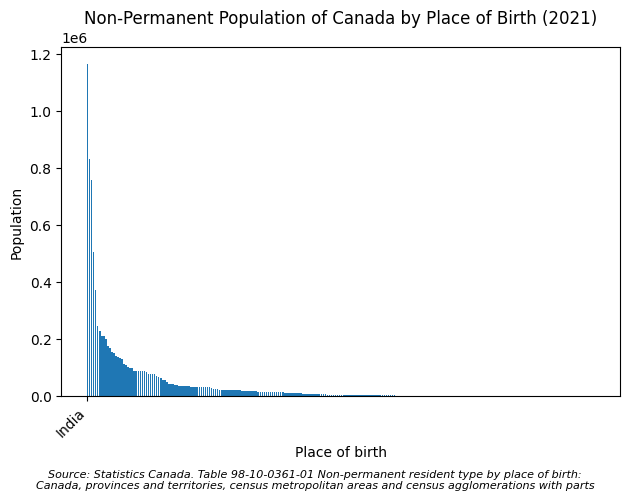

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

x = df_canada_nations_clean_final["Place of birth (290)"]
y = df_canada_nations_clean_final["Non-permanent resident type (10):Total - Non-permanent resident type[1]"]

positions = range(len(y))
ax.bar(positions, y)

max_pos = y.values.argmax()
ax.set_xticks([max_pos])
ax.set_xticklabels([x.iloc[max_pos]])

ax.set_title("Non-Permanent Population of Canada by Place of Birth (2021)")
ax.set_xlabel("Place of birth")
ax.set_ylabel("Population")

plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)

plt.figtext(
    0.5, -0.03,
    "Source: Statistics Canada. Table 98-10-0361-01 Non-permanent resident type by place of birth:\n"
    "Canada, provinces and territories, census metropolitan areas and census agglomerations with parts",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()

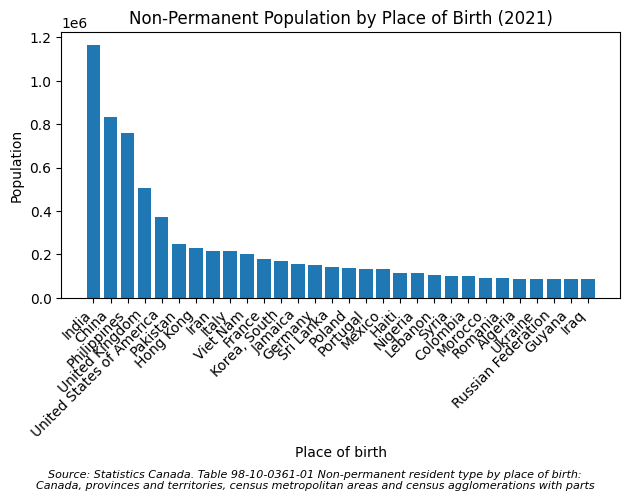

In [16]:
import matplotlib.pyplot as plt

n = 30
df_top = df_canada_nations_clean_final.nlargest(
    n,
    "Non-permanent resident type (10):Total - Non-permanent resident type[1]"
)

fig, ax = plt.subplots()

ax.bar(
    df_top["Place of birth (290)"],
    df_top["Non-permanent resident type (10):Total - Non-permanent resident type[1]"]
)

ax.set_xlabel("Place of birth")
ax.set_ylabel("Population")
ax.set_title("Non-Permanent Population by Place of Birth (2021)")

plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)

plt.figtext(
    0.5, -0.03,
    "Source: Statistics Canada. Table 98-10-0361-01 Non-permanent resident type by place of birth:\n"
    "Canada, provinces and territories, census metropolitan areas and census agglomerations with parts",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()